# Azure AI Evaluation Dashboard
This notebook visualizes the evaluation results from the Azure AI Evaluation SDK.

## 1. Imports & Load Data

In [11]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

%matplotlib inline

# Load evaluation results
results_path = os.path.join(os.getcwd(), "..", "output_files", "myeval_test_results.json")
with open(results_path, "r") as f:
    data = json.load(f)

rows = data["rows"]
metrics = data["metrics"]
print(f"Loaded {len(rows)} evaluation rows")

Loaded 6 evaluation rows


## 2. Extract Per-Row Data

In [12]:
queries = [r["inputs.query"] for r in rows]
short_queries = [q if len(q) <= 30 else q[:27] + "..." for q in queries]

groundedness_scores = [r["outputs.groundedness.groundedness"] for r in rows]
coherence_scores = [r["outputs.coherence.coherence"] for r in rows]
fluency_scores = [r["outputs.fluency.fluency"] for r in rows]
relevance_scores = [r["outputs.relevance.relevance"] for r in rows]
f1_scores = [r["outputs.f1_score.f1_score"] for r in rows]

# Read thresholds from the JSON data
thresholds = {
    "groundedness": rows[0]["outputs.groundedness.groundedness_threshold"],
    "coherence": rows[0]["outputs.coherence.coherence_threshold"],
    "fluency": rows[0]["outputs.fluency.fluency_threshold"],
    "relevance": rows[0]["outputs.relevance.relevance_threshold"],
    "f1_score": rows[0]["outputs.f1_score.f1_threshold"],
}
print("Thresholds read from JSON:", thresholds)

colors = {
    "groundedness": "#e74c3c",
    "coherence": "#3498db",
    "fluency": "#2ecc71",
    "relevance": "#f39c12",
    "f1_score": "#9b59b6",
}
bar_colors = [colors["groundedness"], colors["coherence"], colors["fluency"], colors["relevance"], colors["f1_score"]]

Thresholds read from JSON: {'groundedness': 3, 'coherence': 3, 'fluency': 3, 'relevance': 3, 'f1_score': 0.5}


## 3. Threshold vs Achieved Score
Grouped bar chart comparing each metric's threshold (read from the JSON) against the actual average score achieved. Bars in green indicate the threshold was met; red indicates it was not.

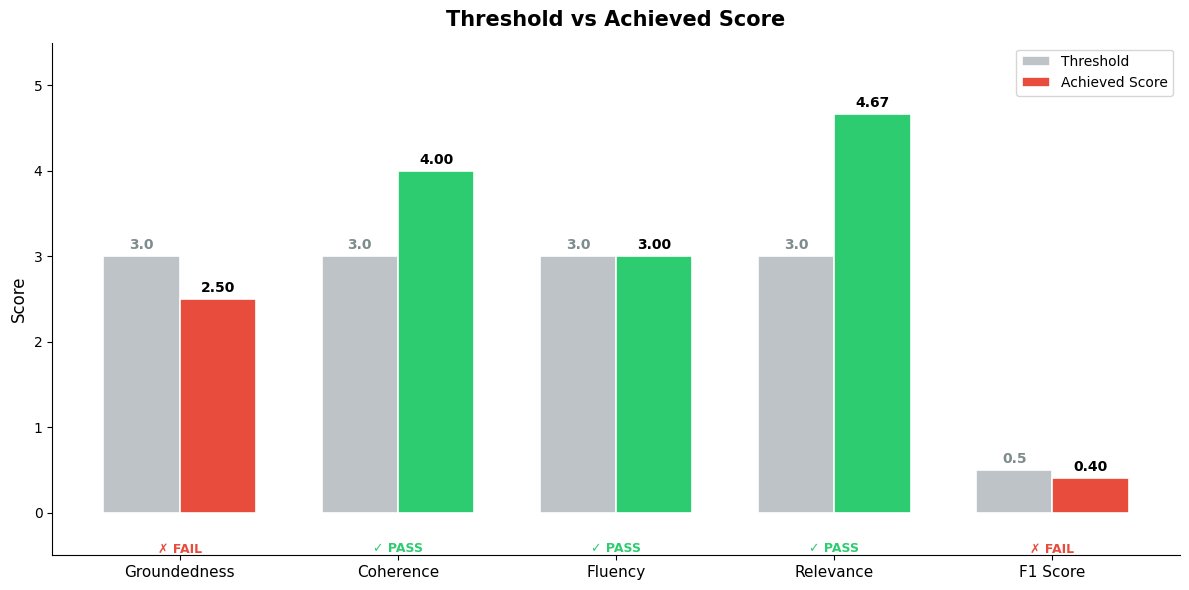

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 6))
agg_labels = ["Groundedness", "Coherence", "Fluency", "Relevance", "F1 Score"]
agg_values = [
    metrics["groundedness.groundedness"],
    metrics["coherence.coherence"],
    metrics["fluency.fluency"],
    metrics["relevance.relevance"],
    metrics["f1_score.f1_score"],
]
threshold_values = [
    thresholds["groundedness"],
    thresholds["coherence"],
    thresholds["fluency"],
    thresholds["relevance"],
    thresholds["f1_score"],
]

x = np.arange(len(agg_labels))
width = 0.35

# Threshold bars (light gray)
bars_thresh = ax1.bar(x - width/2, threshold_values, width, label="Threshold",
                       color="#bdc3c7", edgecolor="white", linewidth=1.2)
# Achieved score bars (colored by pass/fail)
achieved_colors = ["#2ecc71" if agg_values[i] >= threshold_values[i] else "#e74c3c" for i in range(len(agg_labels))]
bars_achieved = ax1.bar(x + width/2, agg_values, width, label="Achieved Score",
                         color=achieved_colors, edgecolor="white", linewidth=1.2)

# Add value labels on threshold bars
for bar, val in zip(bars_thresh, threshold_values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, f"{val:.1f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold", color="#7f8c8d")

# Add value labels on achieved bars
for bar, val in zip(bars_achieved, agg_values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, f"{val:.2f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

# Add pass/fail indicators
for i in range(len(agg_labels)):
    status = "✓ PASS" if agg_values[i] >= threshold_values[i] else "✗ FAIL"
    status_color = "#2ecc71" if agg_values[i] >= threshold_values[i] else "#e74c3c"
    ax1.text(x[i], -0.35, status, ha="center", va="top", fontsize=9,
             fontweight="bold", color=status_color)

ax1.set_ylim(-0.5, 5.5)
ax1.set_xticks(x)
ax1.set_xticklabels(agg_labels, fontsize=11)
ax1.set_ylabel("Score", fontsize=12)
ax1.set_title("Threshold vs Achieved Score", fontsize=15, fontweight="bold", pad=12)
ax1.legend(fontsize=10, loc="upper right")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Binary Pass Rate per Metric
Horizontal bar chart showing the percentage of queries that passed each metric's threshold.

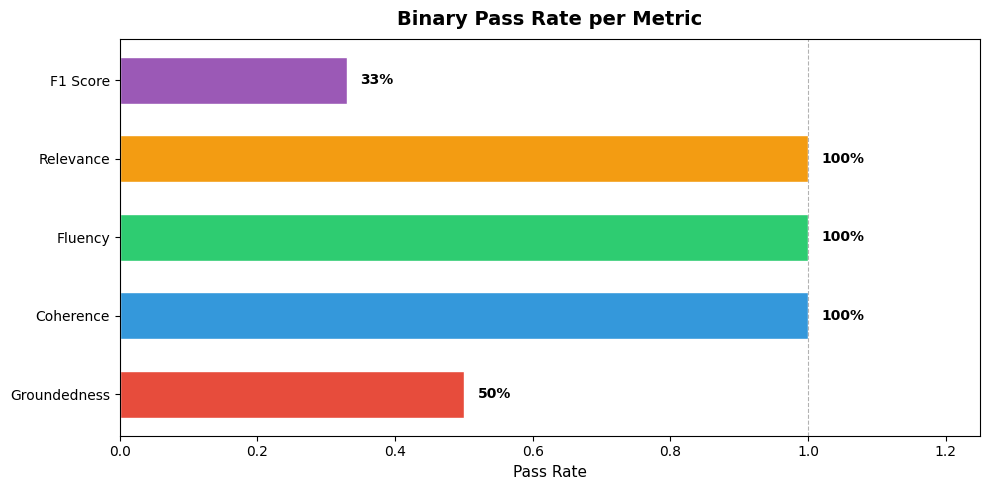

In [14]:
fig, ax2 = plt.subplots(figsize=(10, 5))
binary_labels = ["Groundedness", "Coherence", "Fluency", "Relevance", "F1 Score"]
binary_values = [
    metrics["groundedness.binary_aggregate"],
    metrics["coherence.binary_aggregate"],
    metrics["fluency.binary_aggregate"],
    metrics["relevance.binary_aggregate"],
    metrics["f1_score.binary_aggregate"],
]
bar_positions = np.arange(len(binary_labels))
bars2 = ax2.barh(bar_positions, binary_values, color=bar_colors, edgecolor="white", height=0.6)
for bar, val in zip(bars2, binary_values):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height() / 2, f"{val * 100:.0f}%",
             ha="left", va="center", fontsize=10, fontweight="bold")
ax2.set_yticks(bar_positions)
ax2.set_yticklabels(binary_labels, fontsize=10)
ax2.set_xlim(0, 1.25)
ax2.set_xlabel("Pass Rate", fontsize=11)
ax2.set_title("Binary Pass Rate per Metric", fontsize=14, fontweight="bold", pad=10)
ax2.axvline(x=1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Per-Query Radar Chart
Radar chart overlaying all queries to show the score profile for each. F1 is scaled \u00d75 to fit the 0\u20135 range of other metrics.

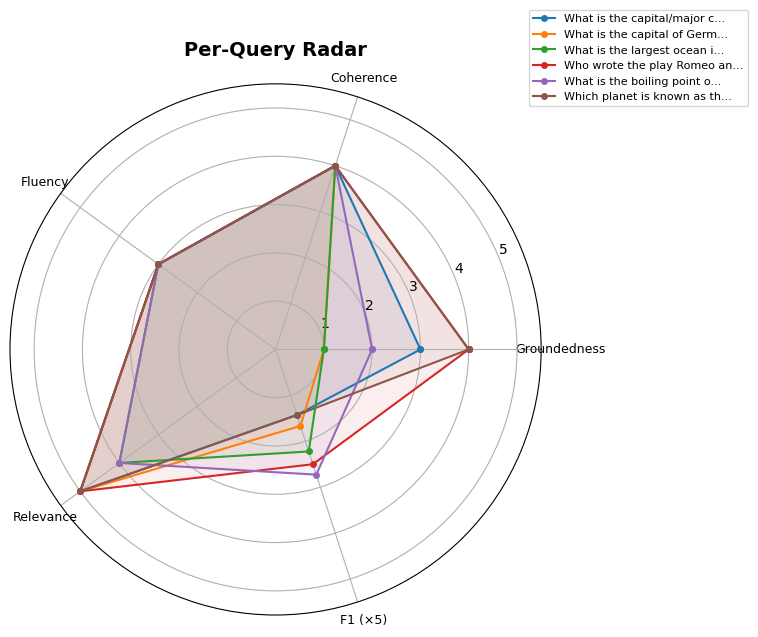

In [15]:
fig, ax3 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
categories = ["Groundedness", "Coherence", "Fluency", "Relevance", "F1 (\u00d75)"]
n_cats = len(categories)
angles = np.linspace(0, 2 * np.pi, n_cats, endpoint=False).tolist()
angles += angles[:1]

for i, query in enumerate(short_queries):
    values = [
        groundedness_scores[i],
        coherence_scores[i],
        fluency_scores[i],
        relevance_scores[i],
        f1_scores[i] * 5,
    ]
    values += values[:1]
    ax3.plot(angles, values, "o-", linewidth=1.5, label=query, markersize=4)
    ax3.fill(angles, values, alpha=0.08)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories, fontsize=9)
ax3.set_ylim(0, 5.5)
ax3.set_title("Per-Query Radar", fontsize=14, fontweight="bold", pad=20)
ax3.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=8)
plt.tight_layout()
plt.show()

## 6. Per-Query Metric Breakdown
Grouped bar chart comparing all five metrics side-by-side for each query.

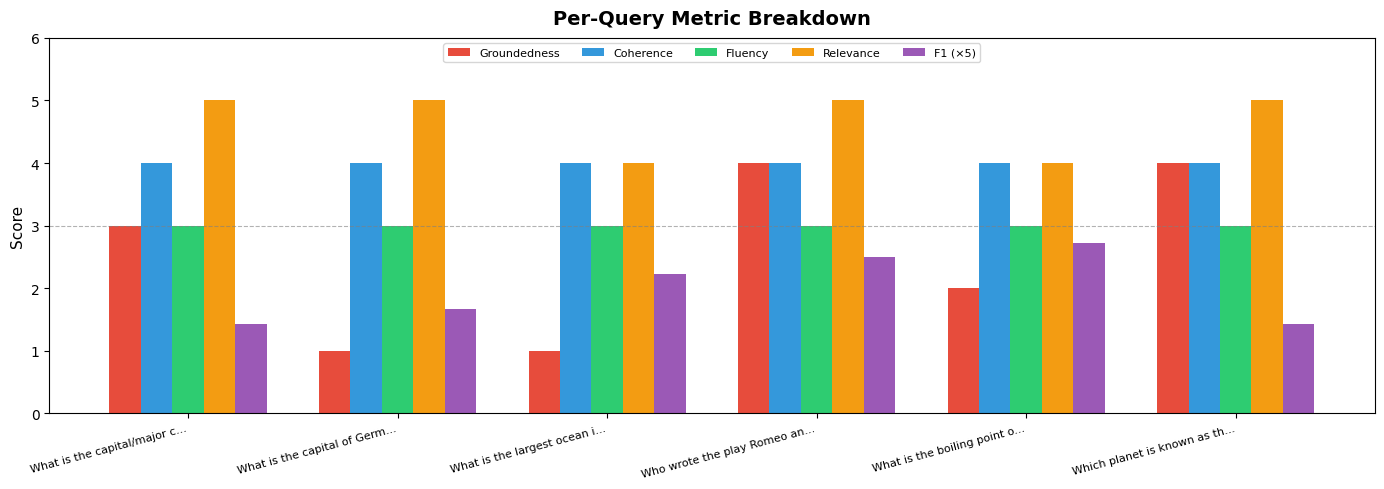

In [16]:
fig, ax4 = plt.subplots(figsize=(14, 5))
x = np.arange(len(queries))
width = 0.15
ax4.bar(x - 2 * width, groundedness_scores, width, label="Groundedness", color=colors["groundedness"])
ax4.bar(x - width, coherence_scores, width, label="Coherence", color=colors["coherence"])
ax4.bar(x, fluency_scores, width, label="Fluency", color=colors["fluency"])
ax4.bar(x + width, relevance_scores, width, label="Relevance", color=colors["relevance"])
ax4.bar(x + 2 * width, [s * 5 for s in f1_scores], width, label="F1 (\u00d75)", color=colors["f1_score"])
ax4.set_xticks(x)
ax4.set_xticklabels(short_queries, fontsize=8, rotation=15, ha="right")
ax4.set_ylabel("Score", fontsize=11)
ax4.set_ylim(0, 6)
ax4.set_title("Per-Query Metric Breakdown", fontsize=14, fontweight="bold", pad=10)
ax4.legend(fontsize=8, ncol=5, loc="upper center")
ax4.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

## 7. Pass/Fail Heatmap
Color-coded grid showing pass (green) vs fail (red) for every query\u00d7metric combination.

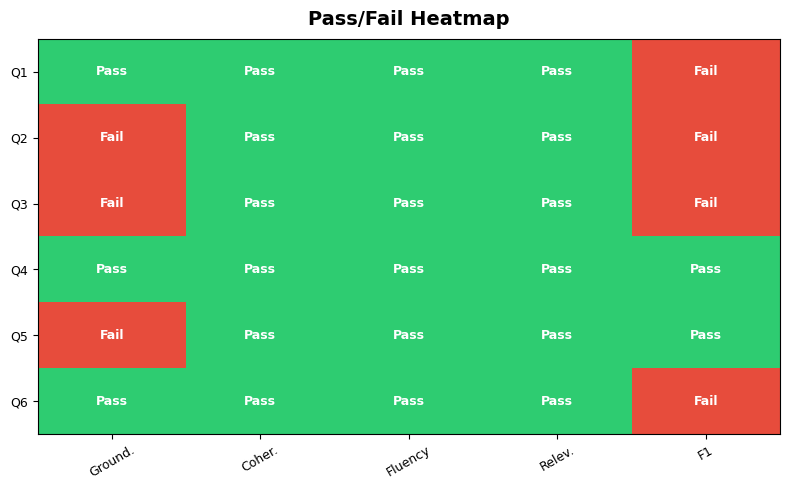

In [17]:
fig, ax5 = plt.subplots(figsize=(8, 5))
result_matrix = []
for r in rows:
    row_results = [
        1 if r["outputs.groundedness.groundedness_result"] == "pass" else 0,
        1 if r["outputs.coherence.coherence_result"] == "pass" else 0,
        1 if r["outputs.fluency.fluency_result"] == "pass" else 0,
        1 if r["outputs.relevance.relevance_result"] == "pass" else 0,
        1 if r["outputs.f1_score.f1_result"] == "pass" else 0,
    ]
    result_matrix.append(row_results)

result_array = np.array(result_matrix)
cmap = plt.cm.colors.ListedColormap(["#e74c3c", "#2ecc71"])
im = ax5.imshow(result_array, cmap=cmap, aspect="auto", vmin=0, vmax=1)
ax5.set_xticks(range(5))
ax5.set_xticklabels(["Ground.", "Coher.", "Fluency", "Relev.", "F1"], fontsize=9, rotation=30)
ax5.set_yticks(range(len(queries)))
ax5.set_yticklabels([f"Q{i+1}" for i in range(len(queries))], fontsize=9)
ax5.set_title("Pass/Fail Heatmap", fontsize=14, fontweight="bold", pad=10)
for i in range(result_array.shape[0]):
    for j in range(result_array.shape[1]):
        label = "Pass" if result_array[i, j] == 1 else "Fail"
        ax5.text(j, i, label, ha="center", va="center", fontsize=9,
                 color="white", fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Token Usage by Metric
Pie chart showing how token consumption is distributed across the GPT-judged metrics (groundedness, coherence, fluency, relevance).

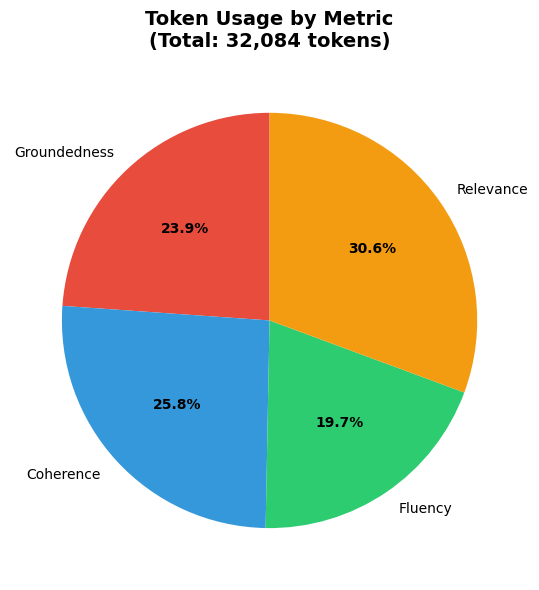

In [18]:
fig, ax6 = plt.subplots(figsize=(8, 6))
metric_names = ["Groundedness", "Coherence", "Fluency", "Relevance"]
total_tokens = []
for metric_key in ["groundedness", "coherence", "fluency", "relevance"]:
    tokens = sum(r[f"outputs.{metric_key}.{metric_key}_total_tokens"] for r in rows)
    total_tokens.append(tokens)
wedges, texts, autotexts = ax6.pie(
    total_tokens, labels=metric_names, autopct="%1.1f%%",
    colors=[colors["groundedness"], colors["coherence"], colors["fluency"], colors["relevance"]],
    startangle=90, textprops={"fontsize": 10}
)
for t in autotexts:
    t.set_fontweight("bold")
ax6.set_title(f"Token Usage by Metric\n(Total: {sum(total_tokens):,} tokens)", fontsize=14, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()

## 9. F1 Score per Query
Bar chart of F1 scores comparing each response against the ground truth. Green bars pass the 0.5 threshold; red bars fail.

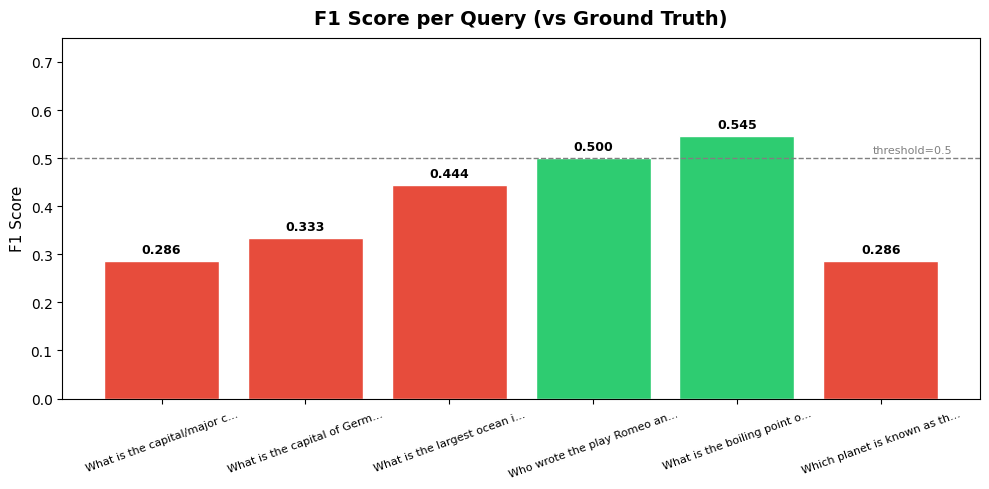

In [19]:
fig, ax7 = plt.subplots(figsize=(10, 5))
f1_colors_bar = ["#2ecc71" if s >= 0.5 else "#e74c3c" for s in f1_scores]
bars7 = ax7.bar(short_queries, f1_scores, color=f1_colors_bar, edgecolor="white")
for bar, val in zip(bars7, f1_scores):
    ax7.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{val:.3f}",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax7.axhline(y=0.5, color="gray", linestyle="--", linewidth=1)
ax7.text(len(queries) - 0.5, 0.51, "threshold=0.5", fontsize=8, color="gray", ha="right")
ax7.set_ylim(0, 0.75)
ax7.set_ylabel("F1 Score", fontsize=11)
ax7.set_title("F1 Score per Query (vs Ground Truth)", fontsize=14, fontweight="bold", pad=10)
ax7.tick_params(axis="x", rotation=20, labelsize=8)
plt.tight_layout()
plt.show()

## 10. Groundedness Deep Dive
Horizontal bar chart showing groundedness scores per query. Green bars pass (\u2265 3); red bars fail. This is typically the weakest metric when the provided context is too sparse.

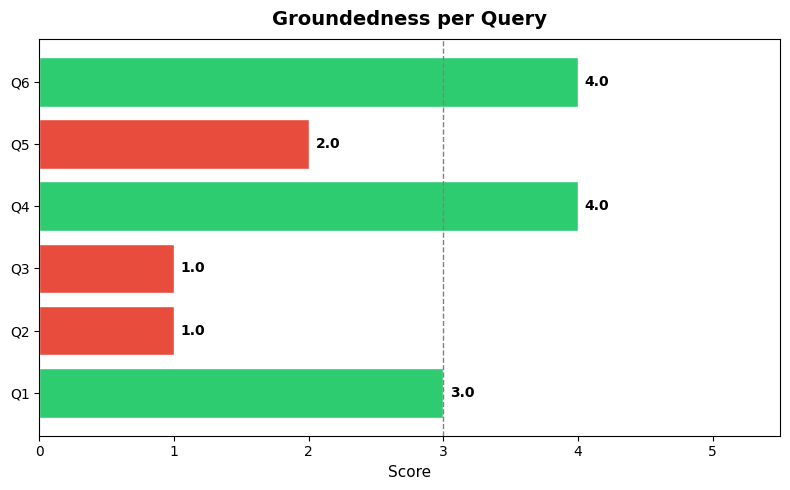

In [20]:
fig, ax8 = plt.subplots(figsize=(8, 5))
g_colors = ["#2ecc71" if s >= 3 else "#e74c3c" for s in groundedness_scores]
bars8 = ax8.barh([f"Q{i+1}" for i in range(len(queries))], groundedness_scores, color=g_colors, edgecolor="white")
for bar, val in zip(bars8, groundedness_scores):
    ax8.text(val + 0.05, bar.get_y() + bar.get_height() / 2, f"{val:.1f}",
             ha="left", va="center", fontsize=10, fontweight="bold")
ax8.axvline(x=3, color="gray", linestyle="--", linewidth=1)
ax8.set_xlim(0, 5.5)
ax8.set_xlabel("Score", fontsize=11)
ax8.set_title("Groundedness per Query", fontsize=14, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()